In [15]:
import geopandas as gpd
import pandas as pd
from shapely.wkt import loads

In [6]:
gdf_regions = gpd.read_file("UK_English_Regions.shp")
gdf_regions_extra = gdf_regions[0:3][['geo_label', 'geometry']].rename(columns={'geo_label': 'REGION_NAME'})
gdf_regions_england = gdf_regions[3:][['rgn17nm', 'geometry']].rename(columns={'rgn17nm': 'REGION_NAME'})

assert len(gdf_regions) == len(gdf_regions_extra) + len(gdf_regions_england)

<Axes: >

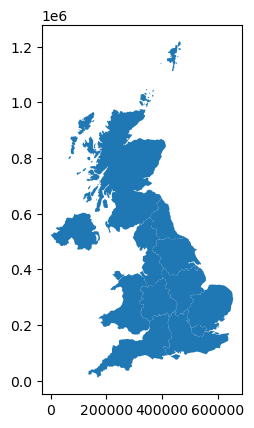

In [8]:
gdf_merged = pd.concat([gdf_regions_extra, gdf_regions_england])
gdf_merged.plot()

In [9]:
gdf_merged.to_csv("regions_shapes.csv", index=False)

In [16]:
####### get region for every postcode
uk_postcode_areas = gpd.read_file("uk_postcodes.csv")
uk_postcode_areas["GEOMETRY"] = uk_postcode_areas["GEOMETRY"].apply(loads)
uk_postcode_areas = gpd.GeoDataFrame(uk_postcode_areas, geometry="GEOMETRY", crs="EPSG:4326")
uk_postcode_areas

,POSTCODE,POSTCODE_STRIP,LATITUDE,LONGITUDE,GEOMETRY
0,AB10 1XG,AB101XG,57.144156,-2.114864,POINT (-2.11486 57.14416)
1,AB10 6RN,AB106RN,57.137871,-2.121487,POINT (-2.12149 57.13787)
2,AB10 7JB,AB107JB,57.124274,-2.127206,POINT (-2.12721 57.12427)
3,AB11 5QN,AB115QN,57.142701,-2.093295,POINT (-2.0933 57.1427)
4,AB11 6UL,AB116UL,57.137468,-2.112455,POINT (-2.11246 57.13747)
...,...,...,...,...,...
1794529,YO7 4FB,YO74FB,54.243953,-1.472731,POINT (-1.47273 54.24395)
1794530,YO7 9DN,YO79DN,54.232597,-1.328747,POINT (-1.32875 54.2326)
1794531,YO8 4FS,YO84FS,53.779924,-1.069318,POINT (-1.06932 53.77992)
1794532,YO8 6DX,YO86DX,53.809575,-0.923888,POINT (-0.92389 53.80958)


In [22]:
region_shapes = gdf_merged.to_crs(4326)

assert uk_postcode_areas.crs == region_shapes.crs

In [ ]:
uk_pc_inc_region = gpd.sjoin(
    uk_postcode_areas, region_shapes, how="right", predicate="within"
)

In [26]:
uk_pc_inc_region.rename(columns={"REGION_NAME": "REGION"}, inplace=True)

In [28]:
uk_pc_inc_region

,index_left,POSTCODE,POSTCODE_STRIP,LATITUDE,LONGITUDE,REGION,geometry
0,1583821,BT70 3NY,BT703NY,54.512217,-6.831684,Northern Ireland,"POLYGON ((-5.44122 54.47729, -5.43663 54.46767..."
0,1583822,BT4 1PW,BT41PW,54.602653,-5.878404,Northern Ireland,"POLYGON ((-5.44122 54.47729, -5.43663 54.46767..."
0,1583823,BT9 5PG,BT95PG,54.552294,-5.969607,Northern Ireland,"POLYGON ((-5.44122 54.47729, -5.43663 54.46767..."
0,1583826,BT39 9TS,BT399TS,54.777369,-5.952764,Northern Ireland,"POLYGON ((-5.44122 54.47729, -5.43663 54.46767..."
0,1583829,BT5 6ED,BT56ED,54.59176,-5.871559,Northern Ireland,"POLYGON ((-5.44122 54.47729, -5.43663 54.46767..."
...,...,...,...,...,...,...,...
11,1794287,TR7 3GG,TR73GG,50.415482,-5.03798,South West,"POLYGON ((-1.66575 51.98749, -1.66253 51.964, ..."
11,1794288,TR7 9EZ,TR79EZ,50.414337,-5.079803,South West,"POLYGON ((-1.66575 51.98749, -1.66253 51.964, ..."
11,1794289,TR8 4TY,TR84TY,50.402879,-5.030052,South West,"POLYGON ((-1.66575 51.98749, -1.66253 51.964, ..."
11,1794290,TR8 4UX,TR84UX,50.412294,-5.043984,South West,"POLYGON ((-1.66575 51.98749, -1.66253 51.964, ..."


In [29]:
uk_pc_inc_region[['POSTCODE','LATITUDE','LONGITUDE','REGION']].to_csv("uk_postcode_region_mapping.csv", index=False)

In [39]:
#### comparing uk REGIONS
df2 = pd.read_csv('uk_regions_shapes.csv')['REGION']
df2.unique()

array(['Northern Ireland', 'Scotland', 'Wales', 'North East',
       'North West', 'Yorkshire and the Humber', 'East Midlands',
       'West Midlands', 'East of England', 'London', 'South East',
       'South West'], dtype=object)

In [36]:
df1 = pd.read_csv('uk_county_region_mapping.csv')
pd.Series(df1['REGION'].unique())

0           Crown Dependencies
1                East Midlands
2              East of England
3                       London
4           North East England
5           North West England
6             Northern Ireland
7                     Scotland
8           South East England
9           South West England
10                       Wales
11               West Midlands
12    Yorkshire and the Humber
dtype: object